In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

Sample Rate: 22050 Hz | Shape: (117601,) | Duration: 5.33s


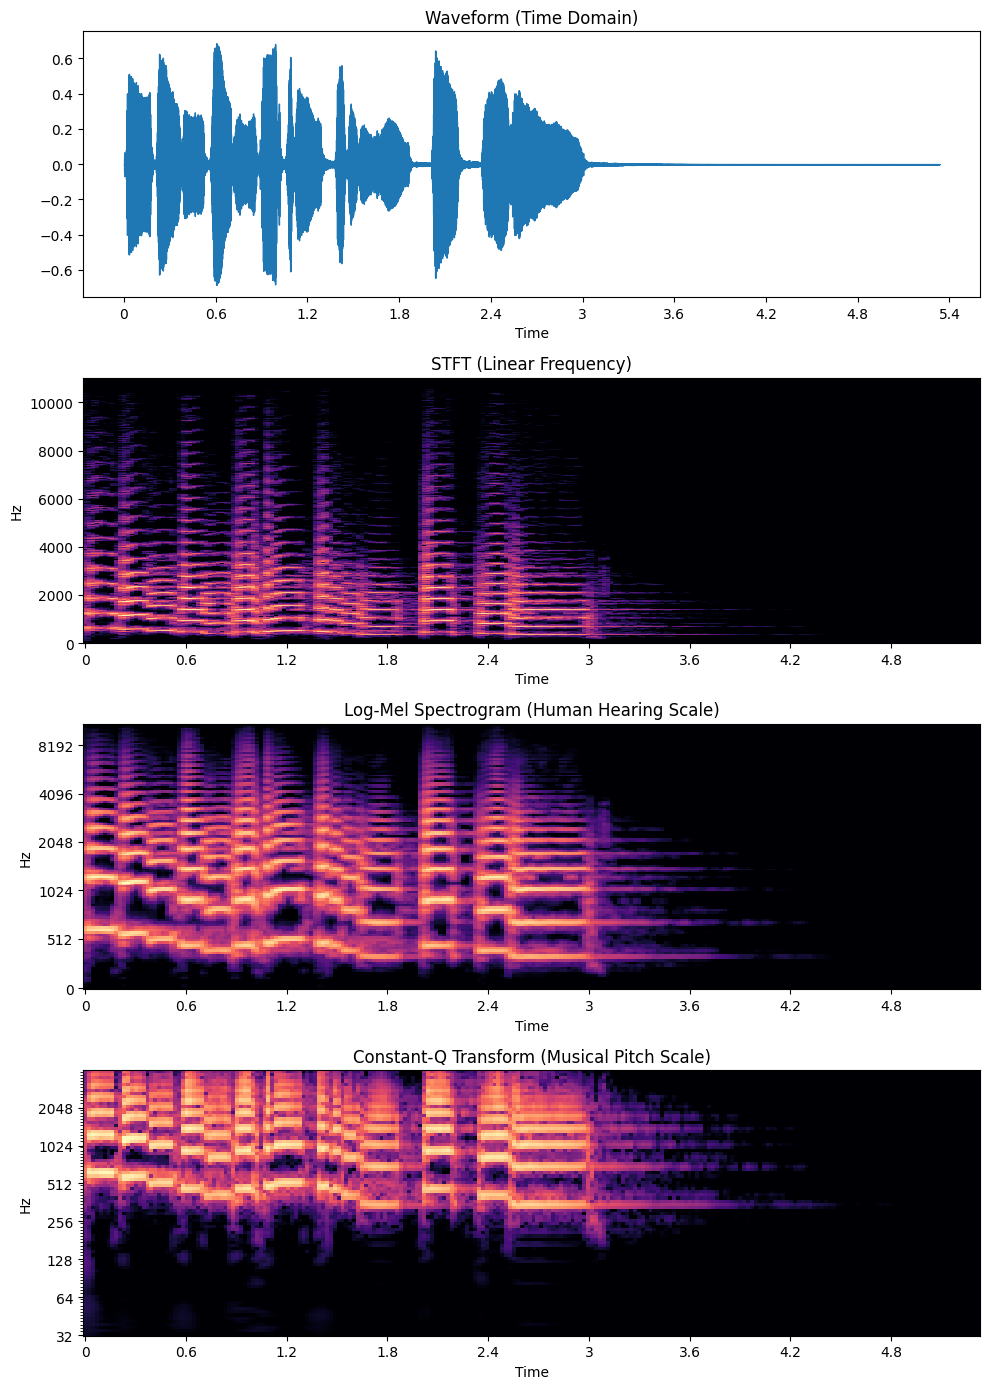

In [2]:

# Load a sample file (replace with an actual ESC-50 path to test real data)
y, sr = librosa.load(librosa.ex('trumpet'), sr=22050)

print(f"Sample Rate: {sr} Hz | Shape: {y.shape} | Duration: {librosa.get_duration(y=y, sr=sr):.2f}s")

# Setup a 4-panel figure
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(10, 14))

# 1. Waveform
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set_title('Waveform (Time Domain)')

# 2. STFT (Linear Frequency)
D_db = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=2048, hop_length=512)), ref=np.max)
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='linear', ax=ax[1])
ax[1].set_title('STFT (Linear Frequency)')

# 3. Log-Mel Spectrogram
mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax[2])
ax[2].set_title('Log-Mel Spectrogram (Human Hearing Scale)')

# 4. Constant-Q Transform (CQT)
cqt_db = librosa.amplitude_to_db(np.abs(librosa.cqt(y, sr=sr, hop_length=512, bins_per_octave=12)), ref=np.max)
librosa.display.specshow(cqt_db, sr=sr, x_axis='time', y_axis='cqt_hz', ax=ax[3])
ax[3].set_title('Constant-Q Transform (Musical Pitch Scale)')

plt.tight_layout()
plt.show()